# 3. Georeferencing

The package has two methods to compute the latitude and longitude of every pixel:

| | `processing.project` | `georef_paulr` |
|---|---|---|
| view directions | one set of calibrated viewing angles for all channels | per-pixel calibration of each channel |
| channel alignment | not considered | boresight offsets per channel and campaign |
| surface | flat, at sea level | plane at `ref_height` above the WGS84 ellipsoid, found iteratively |
| extra dependency | -- | [`mounttree`](https://pypi.org/project/mounttree/) |

`campaign.georef` runs either one on a time slice. `georef_paulr.georef_frame` and `georef_paulr.georef_series` work with any navigation data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from velox_tools import campaign, georef_paulr

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def distance(lat1, lon1, lat2, lon2):
    """Great-circle distance (m)."""
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(v, dtype=float)) for v in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371e3 * np.arcsin(np.sqrt(a))

## A single frame

`georef_frame` needs the aircraft position and attitude at the frame time. With `footprint=True`, the result is on the 635 x 507 grid of the final images; otherwise it is on the 640 x 512 grid of the sensor.

In [2]:
t = slice('2024-08-25T12:30:00', '2024-08-25T12:30:09')
ds = campaign.load_velox(t, channels=3)
nav = campaign.interp_nav(campaign.load_nav(t), ds.time)
n0 = nav.isel(time=0)
aircraft = dict(lat=float(n0['lat']), lon=float(n0['lon']), height=float(n0['alt']),
                roll=float(n0['roll']), pitch=float(n0['pitch']), yaw=float(n0['hdg']))

frame = georef_paulr.georef_frame(**aircraft, channel=3, campaign='PERCUSION', footprint=True)
frame

<xarray.Dataset> Size: 8MB
Dimensions:  (x-pixel: 635, y-pixel: 507)
Coordinates:
  * x-pixel  (x-pixel) int64 5kB 0 1 2 3 4 5 6 7 ... 628 629 630 631 632 633 634
  * y-pixel  (y-pixel) int64 4kB 0 1 2 3 4 5 6 7 ... 500 501 502 503 504 505 506
Data variables:
    lat      (x-pixel, y-pixel) float64 3MB 5.151 5.151 5.15 ... 5.047 5.047
    lon      (x-pixel, y-pixel) float64 3MB -33.07 -33.07 -33.07 ... -33.1 -33.1
    height   (x-pixel, y-pixel) float64 3MB 6.407e-07 6.342e-07 ... 2.971e-07
Attributes:
    description:  Georeferenced VELOX pixels (mounttree/PaulR method)
    ref_height:   0.0
    channel:      3
    campaign:     PERCUSION

In [3]:
across = distance(frame.lat[0, 253], frame.lon[0, 253], frame.lat[-1, 253], frame.lon[-1, 253])
along = distance(frame.lat[317, 0], frame.lon[317, 0], frame.lat[317, -1], frame.lon[317, -1])
print(f'frame footprint at {aircraft["height"]:.0f} m altitude: {across / 1e3:.1f} km x {along / 1e3:.1f} km')

frame footprint at 13895 m altitude: 9.0 km x 7.1 km


## A series of frames

`campaign.georef` returns the brightness temperatures of one channel together with `lats`/`lons` per pixel. Drawn on a map, consecutive frames line up:

In [4]:
geo = campaign.georef(t, channel=3)
geo

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 10, x: 635, y: 507)
Coordinates:
  * time       (time) datetime64[ns] 80B 2024-08-25T12:30:00.306000 ... 2024-...
    band       int64 8B 3
  * x          (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y          (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    BT_2D      (time, x, y) float32 13MB dask.array<chunksize=(10, 635, 507), meta=np.ndarray>
    BT_Center  (time) float32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    lats       (time, x, y) float64 26MB 5.151 5.151 5.15 ... 5.04 5.04 5.04
    lons       (time, x, y) float64 26MB -33.07 -33.07 -33.07 ... -33.12 -33.12
    height     (time, x, y) float64 26MB 6.407e-07 6.342e-07 ... 2.617e-07
Attributes:
    campaign:         PERCUSION
    research_flight:  RF07

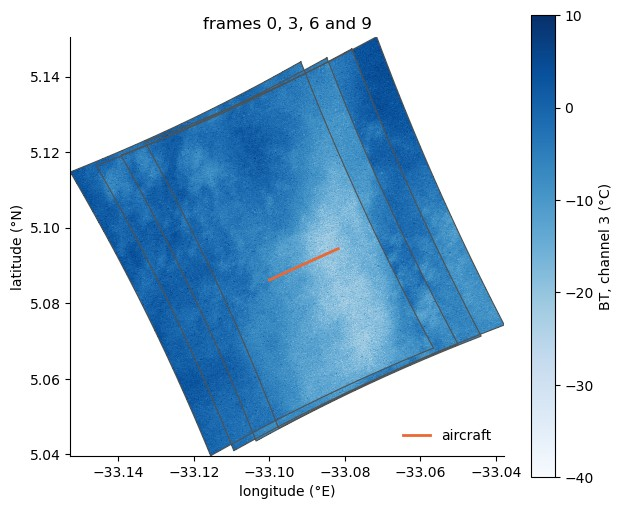

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for i in [0, 3, 6, 9]:
    f = geo.isel(time=i)
    m = ax.pcolormesh(f['lons'][::2, ::2], f['lats'][::2, ::2], f['BT_2D'][::2, ::2][:-1, :-1],
                      cmap='Blues', vmin=-40, vmax=10, rasterized=True)
    edge = np.concatenate([f['lons'][0, :], f['lons'][:, -1], f['lons'][-1, ::-1], f['lons'][::-1, 0]]), \
        np.concatenate([f['lats'][0, :], f['lats'][:, -1], f['lats'][-1, ::-1], f['lats'][::-1, 0]])
    ax.plot(*edge, color='#52514e', linewidth=0.8)
ax.plot(nav['lon'], nav['lat'], color='#eb6834', linewidth=2, label='aircraft')
fig.colorbar(m, label='BT, channel 3 (°C)')
ax.set(xlabel='longitude (°E)', ylabel='latitude (°N)', aspect='equal', title='frames 0, 3, 6 and 9')
ax.legend(frameon=False, loc='lower right');

## The channels look in slightly different directions

Every channel has its own boresight offset angles. The final images are already aligned by a few pixels per channel; the georeferencing accounts for what remains. Distance of the centre pixel of each channel from that of channel 3, for the same aircraft position:

In [6]:
offsets = {}
for channel in campaign.CHANNELS:
    f = georef_paulr.georef_frame(**aircraft, channel=channel, campaign='PERCUSION', footprint=True)
    offsets[channel] = distance(f.lat[317, 253], f.lon[317, 253], frame.lat[317, 253], frame.lon[317, 253])
pd.Series(offsets, name='offset from channel 3 (m)').rename_axis('channel').round(1).to_frame()

,offset from channel 3 (m)
channel,
1,61.8
2,63.3
3,0.0
5,72.4
6,56.4


Calibrations exist for both campaigns:

In [7]:
georef_paulr.available_channels('PERCUSION')

['Channel1', 'Channel2', 'Channel3', 'Channel5', 'Channel6']

## Comparison with `processing.project`

`method='project'` uses the same viewing angles for all channels and ignores the boresight offsets. The two methods differ by:

100%|██████████| 10/10 [00:05<00:00,  1.82it/s]


median 346 m, 95th percentile 430 m


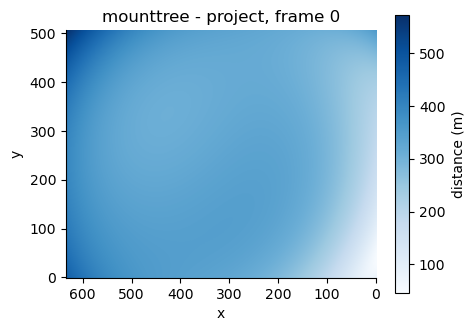

In [8]:
proj = campaign.georef(t, channel=3, method='project')
d = distance(geo['lats'], geo['lons'], proj['lats'], proj['lons'])
print(f'median {np.median(d):.0f} m, 95th percentile {np.percentile(d, 95):.0f} m')

fig, ax = plt.subplots(figsize=(5, 3.6))
m = ax.imshow(d[0].T, origin='lower', cmap='Blues')
ax.invert_xaxis()
ax.set(xlabel='x', ylabel='y', title='mounttree - project, frame 0')
fig.colorbar(m, label='distance (m)');

## Cloud-top height

By default, pixels are projected onto sea level. For clouds, pass the cloud-top height as `ref_height`; otherwise their positions are displaced away from the nadir point. For a cloud top at 10 km, seen from about 14 km:

In [9]:
high = georef_paulr.georef_frame(**aircraft, channel=3, campaign='PERCUSION', footprint=True, ref_height=10000)
shift = distance(frame.lat, frame.lon, high.lat, high.lon)
print(f'centre pixel moves by {float(shift[317, 253]):.0f} m, the frame corners by {float(shift[0, 0]) / 1e3:.1f} km')

centre pixel moves by 374 m, the frame corners by 4.6 km


## Your own navigation data

`georef_series` takes navigation data at the frame times (heading as `yaw`, `heading` or `hdg`). With `rows`, only part of the frame is georeferenced -- this is what `campaign.pushbroom(..., georef=True)` does with the strip rows:

In [10]:
strip = georef_paulr.georef_series(nav, channel=3, campaign='PERCUSION', footprint=True, rows=slice(250, 270))
strip['lat'].sizes

Frozen({'time': 10, 'x-pixel': 635, 'y-pixel': 20})